In [1]:
!pip install pandas
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/pytz-2026.2+computecanada-py3-none-any.whl (from pandas)
Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Looking in indexes: https://download.pytorch.org/whl/cu124
Looking in links: /cvmfs/soft.compu

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import socket
print(socket.gethostname())
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
print("cuda available?", torch.cuda.is_available())
import scipy.linalg as linalg
import matplotlib.pyplot as plt
print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")
import os
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

fc10504
cuda available? False
NumPy:  1.25.2
PyTorch: 2.6.0+cu124
Using cpu device


/localscratch/dtian.46265289.0/env/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
trans_scin_range = (0.01,0.2)
AGN_scin_range = (0.00005,0.2)  ## replicates the observed variability fractions in CHILES VERDES
varbins = np.array([0,0.02,0.1]) ## fractional brightness fluctuation standard deviation. 0.1 Corresponds to a 10% RMS flux density fluctuation
varprobs = np.array([136/185,33/185,16/185]) ## correspond probabilities. Must sum to 1

### LOAD IN THE VARIABILITY: ###

#scinlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
scinlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
#varlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/variation_library.npz')['varlib']
varlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/variation_library.npz')['varlib']

In [4]:
#transientsdata = (np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
transientsdata = (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]

In [ ]:
def make_gaussian_heatmap(binary_target, sigma=2.0):
    """
    binary_target: (H, W) array with a few 1s at feature locations.
    returns:       (H, W) float heatmap, peaks = 1.0 at each feature.
    """
    H, W = binary_target.shape
    heatmap = np.zeros((H, W), dtype=np.float32)

    # locations of the 1s
    ys, xs = np.nonzero(binary_target)

    # precompute kernel radius (3 sigma covers ~99% of the blob)
    radius = int(np.ceil(3 * sigma))

    for cy, cx in zip(ys, xs):
        # bounds of the patch to write into (clipped to image edges)
        y0, y1 = max(0, cy - radius), min(H, cy + radius + 1)
        x0, x1 = max(0, cx - radius), min(W, cx + radius + 1)

        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma ** 2))

        # max-combine so overlapping blobs stay <= 1
        heatmap[y0:y1, x0:x1] = np.maximum(heatmap[y0:y1, x0:x1], g)

    return heatmap

In [ ]:
def gaussian2d(x,y,meanx,meany):

    FWHM = 5

    '''
    returns a 2d gaussian with the right shape
    '''

    return np.exp(-0.5*2.3**2*((x-meanx)**2+(y-meany)**2)/FWHM**2) # factor of 2.3 converts the FWHM to a standard deviation

def genbackground(xlen,ylen,tlen,Nbgnd,noiseamp=0.1):

    x = np.arange(xlen) ## x,y,t arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    #np.random.seed(41)
    rng = np.random.default_rng(123)
    
    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    backgroundfield = np.zeros(noisefield.shape) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Nbgnd,2))

    for i in range(Nbgnd): ## for each background source

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen)) ## generate a uniform random map position

        bgfluxdensity = 10**(2*np.random.rand()-1) ## brightness, right now log-uniform between 0.1 and 10

        layer = bgfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1]) # add the map layer value

        ## apply intrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)

        randfloat = np.random.rand()
        
        if randfloat <= varprobs[0]:
            amp = varbins[0]
        elif randfloat <= varprobs[0]+varprobs[1]:
            amp = varbins[1]
        else:
            amp = varbins[2]
        
        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(AGN_scin_range[1]/AGN_scin_range[0]))*np.random.rand()+np.log10(AGN_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        backgroundfield += layer



    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return backgroundfield,noisefield,positions
        
def gentransients(xlen,ylen,tlen,Ntrans):

    global transientsdata
    #np.random.seed(41)
    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    transient_field = np.zeros((xlen,ylen,tlen)) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Ntrans,2))
    target_map = np.zeros((xlen, ylen))

    for i in range(Ntrans):

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen))

        LCidx = np.random.randint(7000)

        LC = transientsdata[LCidx]
        LC /= np.max(LC)

        transfluxdensity = 10**(np.random.rand()-0.5) ## right now log-uniform between 0.3 and 3 ## change as you see fit

        ## apply the shape of the lightcurve
        
        layer = transfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1])*LC[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(trans_scin_range[1]/trans_scin_range[0]))*np.random.rand()+np.log10(trans_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        transient_field += layer

        target_map[y0[-1]][x0[-1]] = 1
    target_map = make_gaussian_heatmap(target_map)
    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return transient_field,positions,target_map

In [7]:
bg,noise,bgpositions = genbackground(100,100,608,np.random.randint(5, 20),noiseamp = 0.1)
#bg: intrinsic and extrinsic, noise: random, bgpositions: 

In [8]:
transients,transientspositions, target_map = gentransients(100,100,608,np.random.randint(10))

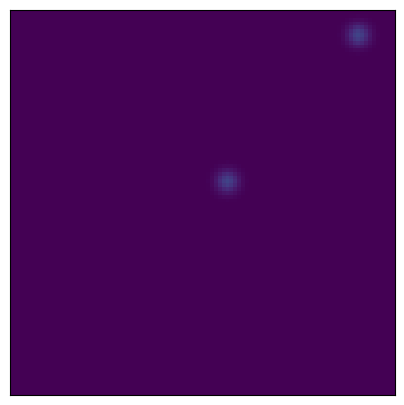

In [9]:
'''
Show the target map, where transient is 1 and rest is 0
'''
plt.figure(figsize = (5,5))
plt.imshow((target_map),vmax = 5,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()

In [10]:
# generates and saves animation frames for the above generated field
for frame in range(100):
    plt.figure(figsize = (5,5))
    plt.imshow((bg+noise+transients)[:,:,6*frame],vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.savefig('/Users/dtian/Documents/Programming/Di_Research/example_animation/frame_%d.png' %frame)
    #plt.show()
    plt.close()

In [ ]:
def genfields(Nfields=10, xlen=100, ylen=100, tlen=608, Nbgnd=15 ,noiseamp=0.1, Ntrans=2):
    combined_fields = []
    backgrounds = []
    noises = []
    transients = []
    bgpositions = []
    transientspositions = []
    target_maps = []
    for field in range(Nfields):
        Nbgnd = np.random.randint(5, 20) #Number of background is from 5 to 19
        Ntrans = np.random.randint(10) #Number of Ntrans is from 0 to 10
        bg,noise,bgposition = genbackground(xlen,ylen,tlen,Nbgnd,noiseamp)
        transient,transientsposition,target_map = gentransients(xlen,ylen,tlen,Ntrans)
        combined_fields.append(bg+noise+transient)
        backgrounds.append(bg)
        noises.append(noise)
        transients.append(transient)
        bgpositions.append(bgposition)
        transientspositions.append(transientsposition)
        target_maps.append(target_map)
    combined_fields = np.array(combined_fields)
    backgrounds = np.array(backgrounds)
    noises = np.array(noises)
    transients = np.array(transients)
    #bgpositions = np.array(bgpositions)
    #transientspositions = np.array(transientspositions)
    target_maps = np.array(target_maps)
    return combined_fields, backgrounds, noises, transients, bgpositions, transientspositions, target_maps

In [ ]:
def normalize_data(data):
    mean = data.mean()
    std = data.std()
    return (data - mean) / std, mean, std

def convert_to_torch_data(data):
    data = torch.tensor(data, dtype=torch.float32)
    data = data.squeeze(0)
    if data.dim() == 4:                       # NHWC -> NCHW
        data = data.permute(0, 3, 1, 2).contiguous()
    data = data.float().to(device)
    return normalize_data(data)

: 

In [13]:
a, b, c, d, e, f, g= genfields(Nfields=200)
X_test,_,_ = convert_to_torch_data(a)
y_test,_,_ = convert_to_torch_data(g)
print(X_test.shape)
print(y_test.shape)
a, b, c, d, e, f, g= genfields(Nfields=2000)
#e = make_gaussian_heatmap(e, sigma=2.0) 
X_train,_,_ = convert_to_torch_data(a)
y_train,y_train_mean,y_train_std = convert_to_torch_data(g)
#b,_,_ = convert_to_torch_data(b)
#c,_,_ = convert_to_torch_data(c)
#d,_,_ = convert_to_torch_data(d)
#e,_,_ = convert_to_torch_data(e)
print(X_train.shape)
print(y_train.shape)


/tmp/ipykernel_421810/1033097795.py:98: RuntimeWarning: invalid value encountered in divide
  LC /= np.max(LC)


torch.Size([200, 608, 100, 100])
torch.Size([200, 100, 100])


: 

: 

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test,  y_test)

batch_size = 256

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection


class HeatmapNet(nn.Module):
    """
    Input:  (N, tlen, 100, 100)   # t as channels
    Output: (N, 100, 100) logits  # per-pixel confidence, pre-sigmoid
    """
    def __init__(self, tlen=608):
        super().__init__()
        # ---- Encoder ----
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, 7, padding=3), nn.BatchNorm2d(96), nn.ReLU(),
        )                                                  # 100x100, 96
        self.enc1  = nn.Sequential(ResBlock(96), ResBlock(96))
        self.down1 = nn.MaxPool2d(2)                       # -> 50x50

        self.enc2  = nn.Sequential(
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192), ResBlock(192),
        )                                                  # 50x50, 192
        self.down2 = nn.MaxPool2d(2)                       # -> 25x25

        self.bottleneck = nn.Sequential(
            nn.Conv2d(192, 384, 3, padding=1), nn.BatchNorm2d(384), nn.ReLU(),
            ResBlock(384), ResBlock(384),
        )                                                  # 25x25, 384

        # ---- Decoder (upsample + concat skips) ----
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(384 + 192, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192),
        )                                                  # 50x50
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(192 + 96, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            ResBlock(96),
        )                                                  # 100x100

        self.head = nn.Conv2d(96, 1, 1)                    # 1-channel logits

    def forward(self, x):
        # if your data is (N, x, y, t):  x = x.permute(0, 3, 1, 2)
        s  = self.stem(x)
        e1 = self.enc1(s)                       # 100x100
        e2 = self.enc2(self.down1(e1))          # 50x50
        b  = self.bottleneck(self.down2(e2))    # 25x25

        d2 = self.dec2(torch.cat([self.up2(b),  e2], dim=1))  # 50x50
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # 100x100
        return self.head(d1).squeeze(1)         # (N, 100, 100) logits

In [ ]:
'''
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))  # skip connection


class NeuralNetwork(nn.Module):
    def __init__(self, n_trans=2, n_params=2, tlen=608):
        super().__init__()
        self.n_trans = n_trans
        self.n_params = n_params

        # large kernel stem to capture broad Gaussian spatial extent
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, kernel_size=7, padding=3),
            nn.BatchNorm2d(96),
            nn.ReLU(),
        )

        # (N, 96, 100, 100)
        self.layer1 = nn.Sequential(
            ResBlock(96),
            ResBlock(96),
            ResBlock(96),
            nn.MaxPool2d(2),         # -> (N, 96, 50, 50)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(96, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            ResBlock(192),
            ResBlock(192),
            ResBlock(192),
            nn.MaxPool2d(2),         # -> (N, 192, 25, 25)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(),
            ResBlock(384),
            ResBlock(384),
            ResBlock(384),
            nn.MaxPool2d(2),         # -> (N, 256, 12, 12)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),            # -> (N, 384*12*12 = 55296)
            nn.Linear(55296, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, n_trans * n_params),
        )

    def forward(self, x):
        # x = x.permute(0, 3, 1, 2)   # (N, x, y, t) -> (N, t, x, y)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x).view(-1, self.n_trans, self.n_params)


#model = NeuralNetwork(tlen=100).to(device)
#print(model)
'''

'\nclass ResBlock(nn.Module):\n    def __init__(self, channels):\n        super().__init__()\n        self.block = nn.Sequential(\n            nn.Conv2d(channels, channels, kernel_size=3, padding=1),\n            nn.BatchNorm2d(channels),\n            nn.ReLU(),\n            nn.Conv2d(channels, channels, kernel_size=3, padding=1),\n            nn.BatchNorm2d(channels),\n        )\n        self.relu = nn.ReLU()\n\n    def forward(self, x):\n        return self.relu(x + self.block(x))  # skip connection\n\n\nclass NeuralNetwork(nn.Module):\n    def __init__(self, n_trans=2, n_params=2, tlen=608):\n        super().__init__()\n        self.n_trans = n_trans\n        self.n_params = n_params\n\n        # large kernel stem to capture broad Gaussian spatial extent\n        self.stem = nn.Sequential(\n            nn.Conv2d(tlen, 96, kernel_size=7, padding=3),\n            nn.BatchNorm2d(96),\n            nn.ReLU(),\n        )\n\n        # (N, 96, 100, 100)\n        self.layer1 = nn.Sequential(

In [ ]:
'''
The hungarian_loss take account the fact that two similar transient 3D image, (A, B, C) and (B, A, C), would be similar but with differnent loss
Hungarian_loss take care of it and make them similar loss
'''

from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def hungarian_loss(pred, target):
    # pred, target: (N, n_trans, n_params)
    batch_size, n_trans = pred.shape[:2]
    total_loss = torch.tensor(0.0, requires_grad=True)

    for i in range(batch_size):
        # pairwise MSE cost matrix between predicted and true transients
        cost = torch.stack([
            torch.stack([F.mse_loss(pred[i, j], target[i, k])
                         for k in range(n_trans)])
            for j in range(n_trans)
        ])
        # find optimal assignment (no gradient needed here)
        row_ind, col_ind = linear_sum_assignment(cost.detach().cpu().numpy())
        # sum loss over matched pairs
        matched = sum(cost[r, c] for r, c in zip(row_ind, col_ind))
        total_loss = total_loss + matched / n_trans

    return total_loss / batch_size

In [ ]:
model = HeatmapNet().to(device)
print(model)
loss_fn = hungarian_loss

HeatmapNet(
  (stem): Sequential(
    (0): Conv2d(608, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (enc1): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0
    all_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred)

    test_loss /= num_batches
    all_preds = torch.cat(all_preds, dim=0)
    return all_preds, test_loss  # return both

In [ ]:
X_small = X_train[:2].to(device)
y_small = y_train[:2].to(device)
print(X_small.shape)
print(y_small.shape)

model.train()
pred = model(X_small)
print("Forward:", pred.shape)
loss = hungarian_loss(pred, y_small)
loss.backward()
print("Backward OK, loss:", loss.item())

torch.Size([2, 608, 100, 100])
torch.Size([2, 100, 100])
Forward: torch.Size([2, 100, 100])
Backward OK, loss: 1.514833927154541


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: torch.Size([64, 608, 100, 100])
y_train shape: torch.Size([64, 100, 100])
X_test shape: torch.Size([64, 608, 100, 100])


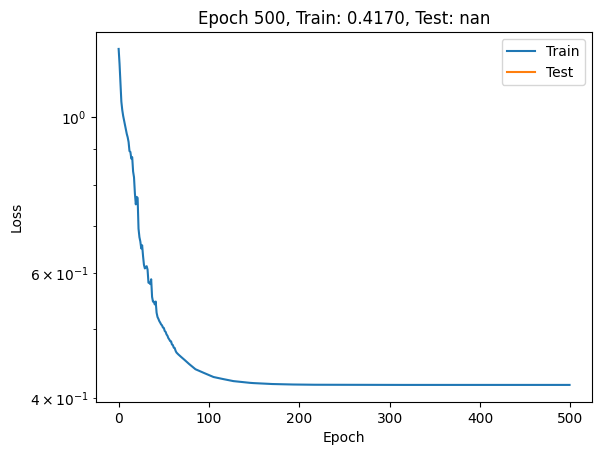

Done!


: 

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

learning_rate = 1e-3
batch_size = 256
epochs = 500
train_losses = []
test_losses = []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)#, verbose=True)

for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    preds, test_loss = test_loop(test_dataloader, model, loss_fn)
    scheduler.step(test_loss)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    clear_output(wait=True)
    plt.clf() 
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses, label='Test')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}')
    plt.legend()
    plt.show()

print("Done!")

In [ ]:
a, b, c, d, e, f, g= genfields(Nfields=200)
X_eval,_,_ = convert_to_torch_data(a)
y_eval,_,_ = convert_to_torch_data(g)

new_dataset = TensorDataset(X_eval, y_eval)
new_dataloader = DataLoader(new_dataset, batch_size=batch_size)

preds, loss = test_loop(new_dataloader, model, loss_fn)

#true_values = torch.cat([y for _, y in new_dataloader], dim=0)

preds = y_train_mean + preds * y_train_std
print(y_eval)
print(preds)

/tmp/ipykernel_1261308/1033097795.py:98: RuntimeWarning: invalid value encountered in divide
  LC /= np.max(LC)


: 

: 